<a href="https://colab.research.google.com/github/PriyanAcharya/ML/blob/main/K_MeansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [ ]:
iris = datasets.load_iris()
X = iris.data[:, :2]

In [ ]:
k = 3
np.random.seed(42)
random_indices = np.random.choice(len(X), k, replace=False)
centroids = X[random_indices]

In [ ]:
def compute_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

In [ ]:
for iteration in range(100):

    clusters = []
    for point in X:
        distances = [compute_distance(point, centroid) for centroid in centroids]
        cluster_index = np.argmin(distances)
        clusters.append(cluster_index)

    clusters = np.array(clusters)

    new_centroids = []
    for i in range(k):
        points = X[clusters == i]
        new_centroids.append(points.mean(axis=0))

    new_centroids = np.array(new_centroids)

    if np.all(centroids == new_centroids):
        break

    centroids = new_centroids

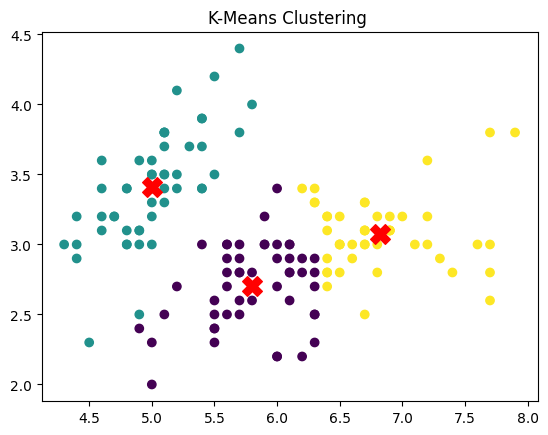

In [ ]:
plt.scatter(X[:,0], X[:,1], c=clusters, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clustering ")
plt.show()

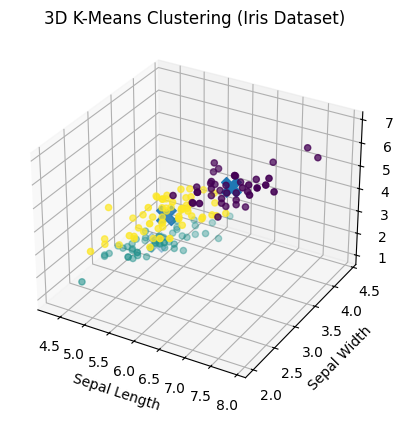

In [ ]:

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

iris = load_iris()

X = iris.data[:, :3]
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels)

ax.scatter(centroids[:, 0],
           centroids[:, 1],
           centroids[:, 2],
           marker='X',
           s=200)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

ax.set_title("3D K-Means Clustering (Iris Dataset)")

plt.show()

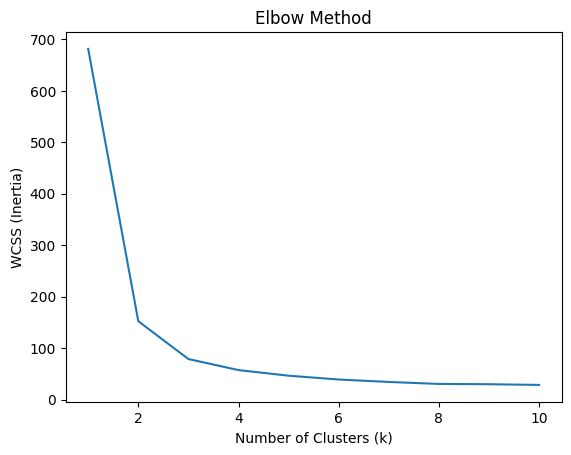

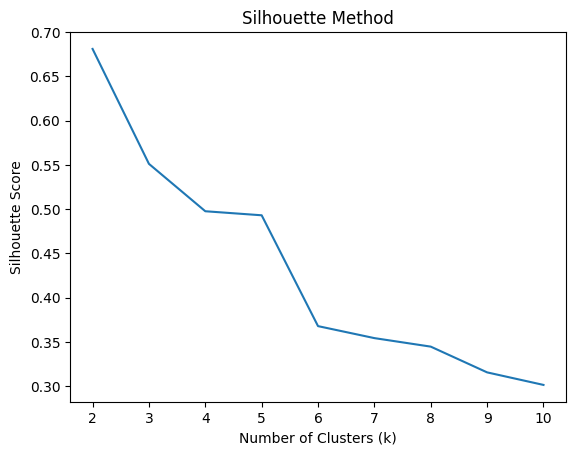

In [ ]:

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()


silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(k_values, silhouette_scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()